# Graph Neural Weather Operators

Notebook 2 showed one way to respect global geometry: replace flat Fourier modes with spherical harmonics. This notebook introduces another route that is central to GraphCast- and AIFS-style systems: represent the atmosphere on a **graph** and learn how information moves along edges.

The forecast problem is still an operator-learning problem:

$$
\mathcal{G}_\theta: X_t \mapsto X_{t+\Delta t}.
$$

The representation changes. Instead of treating $X_t$ as an image or a spectral coefficient vector, we treat it as node features on a graph:

$$
X_t = \{x_i(t)\}_{i=1}^{N}.
$$

This notebook uses a small synthetic graph forecast task. The goal is not to build a competitive weather model. The goal is to understand the design pattern behind graph-based learned forecast operators.

Key references:

- Keisler, [Forecasting Global Weather with Graph Neural Networks](https://arxiv.org/abs/2202.07575)
- ECMWF, [AIFS: a new ECMWF forecasting system](https://www.ecmwf.int/en/newsletter/178/news/aifs-new-ecmwf-forecasting-system)
- ECMWF, [First update to the AIFS](https://www.ecmwf.int/node/28946)

In [1]:
import warnings
warnings.filterwarnings('ignore')

from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

rng = np.random.default_rng(12)
torch.manual_seed(12)

device = torch.device('cpu')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = False
plt.rcParams['image.cmap'] = 'turbo'

## 1. Graphs as spatial representations

A graph gives us a flexible way to describe a spatial domain.

- **Nodes** hold state variables at locations: grid cells, mesh points, stations, or latent points.
- **Edges** define possible information pathways between nodes.
- **Node features** can include temperature, wind, humidity, pressure, coordinates, or static fields.
- **Edge features** can include distance, direction, vertical relationship, or grid hierarchy.

This is useful for weather because the globe is not naturally a flat image. Graphs can represent regular latitude-longitude grids, reduced Gaussian grids, icosahedral meshes, station networks, or latent multi-scale meshes.

In [2]:
def make_lat_lon_grid(n_lat=10, n_lon=20):
    lat = np.linspace(-70.0, 70.0, n_lat)
    lon = np.linspace(0.0, 360.0, n_lon, endpoint=False)
    lon2, lat2 = np.meshgrid(lon, lat)
    return lat2.ravel(), lon2.ravel(), lat2.shape


def build_knn_graph(lat, lon, k=6):
    """Directed k-nearest-neighbor graph using great-circle distance."""
    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)
    xyz = np.column_stack([
        np.cos(lat_rad) * np.cos(lon_rad),
        np.cos(lat_rad) * np.sin(lon_rad),
        np.sin(lat_rad),
    ])
    great_circle = np.arccos(np.clip(xyz @ xyz.T, -1.0, 1.0))

    src, dst = [], []
    for i in range(len(lat)):
        neighbors = np.argsort(great_circle[i])[1:k + 1]
        src.extend([i] * k)
        dst.extend(neighbors.tolist())

    src = np.array(src)
    dst = np.array(dst)
    dlat = lat_rad[dst] - lat_rad[src]
    dlon = (lon_rad[dst] - lon_rad[src] + np.pi) % (2 * np.pi) - np.pi
    edge_attr = np.column_stack([dlat, dlon, great_circle[src, dst]]).astype('float32')
    edge_index = np.vstack([src, dst]).astype('int64')
    return edge_index, edge_attr


lat, lon, grid_shape = make_lat_lon_grid(n_lat=10, n_lon=20)
edge_index_np, edge_attr_np = build_knn_graph(lat, lon, k=6)

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)
node_coords_np = np.column_stack([
    np.sin(lat_rad),
    np.cos(lat_rad),
    np.sin(lon_rad),
    np.cos(lon_rad),
]).astype('float32')

edge_index = torch.tensor(edge_index_np, dtype=torch.long, device=device)
edge_attr = torch.tensor(edge_attr_np, dtype=torch.float32, device=device)
node_coords = torch.tensor(node_coords_np, dtype=torch.float32, device=device)

print(f'nodes: {len(lat)}')
print(f'directed edges: {edge_index.shape[1]}')
print(f'node coordinate features: {node_coords.shape[1]} = sin(lat), cos(lat), sin(lon), cos(lon)')
print(f'edge features: {edge_attr.shape[1]} = dlat, dlon, great-circle distance')

nodes: 200
directed edges: 1200
node coordinate features: 4 = sin(lat), cos(lat), sin(lon), cos(lon)
edge features: 3 = dlat, dlon, great-circle distance


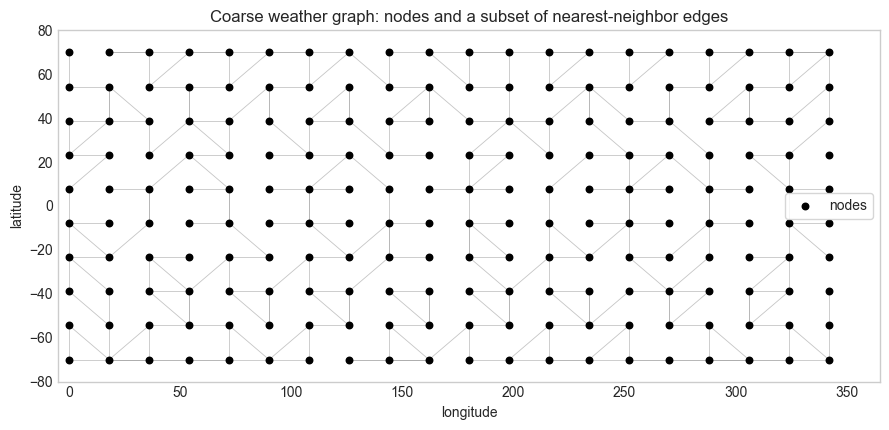

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.scatter(lon, lat, s=22, c='black', zorder=3, label='nodes')

for s, d in edge_index_np.T[::4]:
    lon_pair = [lon[s], lon[d]]
    lat_pair = [lat[s], lat[d]]
    if abs(lon_pair[0] - lon_pair[1]) < 180:
        ax.plot(lon_pair, lat_pair, color='0.65', lw=0.6, alpha=0.65, zorder=1)

ax.set_xlim(-5, 365)
ax.set_ylim(-80, 80)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
ax.set_title('Coarse weather graph: nodes and a subset of nearest-neighbor edges')
ax.legend(frameon=True)
plt.tight_layout()

This graph is deliberately small: 200 nodes and six outgoing edges per node. Production models use much larger and more carefully designed meshes, but the abstraction is the same.

## 2. Message passing as a learned spatial operator

A graph neural network updates node states by passing learned messages along edges. For a directed edge $i \to j$, a simple message-passing layer does three things:

$$
m_{ij} = \phi_e(h_i, h_j, e_{ij}),
$$

$$
\bar{m}_j = \frac{1}{|\mathcal{N}(j)|}\sum_{i \in \mathcal{N}(j)} m_{ij},
$$

$$
h_j^{\mathrm{new}} = h_j + \phi_v(h_j, \bar{m}_j).
$$

Here $h_i$ is the latent state at node $i$, $e_{ij}$ stores edge geometry, and $\phi_e$, $\phi_v$ are neural networks.

This is an operator-learning view: message passing is a learned spatial update rule. Stacking layers lets information travel multiple graph hops, much like increasing a CNN receptive field, but the neighborhood is defined by geometry instead of array indices.

## 3. Encoder, processor, decoder

Modern graph weather models usually separate the computation into three parts:

```text
data grid  ->  encoder  ->  latent graph/mesh  ->  processor  ->  latent graph/mesh  ->  decoder  ->  output grid
```

- The **encoder** moves observed or gridded atmospheric variables into latent node features.
- The **processor** repeatedly updates the latent graph through message passing or attention.
- The **decoder** maps the updated latent state back to the desired variables and grid.

In the toy example below, the data grid and latent graph are the same nodes. That keeps the code readable while preserving the architectural idea.

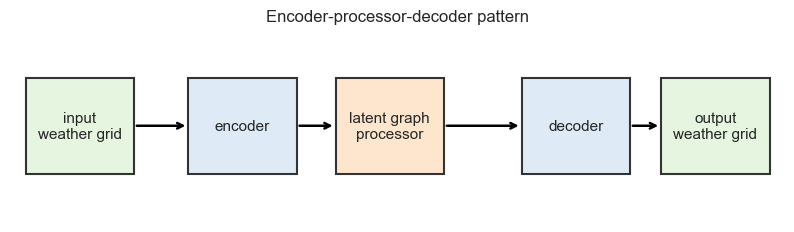

In [4]:
def draw_box(ax, xy, width, height, label, color):
    rect = plt.Rectangle(xy, width, height, facecolor=color, edgecolor='0.2', lw=1.5)
    ax.add_patch(rect)
    ax.text(xy[0] + width / 2, xy[1] + height / 2, label, ha='center', va='center', fontsize=11)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.set_axis_off()
boxes = [
    ((0.02, 0.25), 'input\nweather grid', '#e5f5e0'),
    ((0.23, 0.25), 'encoder', '#deebf7'),
    ((0.42, 0.25), 'latent graph\nprocessor', '#fee6ce'),
    ((0.66, 0.25), 'decoder', '#deebf7'),
    ((0.84, 0.25), 'output\nweather grid', '#e5f5e0'),
]
for xy, label, color in boxes:
    draw_box(ax, xy, 0.14, 0.5, label, color)
for x0, x1 in [(0.16, 0.23), (0.37, 0.42), (0.56, 0.66), (0.80, 0.84)]:
    ax.annotate('', xy=(x1, 0.5), xytext=(x0, 0.5), arrowprops=dict(arrowstyle='->', lw=1.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Encoder-processor-decoder pattern')
plt.show()

## 4. A synthetic one-step forecast task

We will now train a small graph operator on a generated task. Each sample is a smooth scalar field on the coarse global graph. The target is the same underlying field shifted northeastward.

You can read this as a toy advection problem:

$$
q_t(\lambda, \phi) \mapsto q_{t+\Delta t}(\lambda, \phi).
$$

The persistence baseline predicts $q_{t+\Delta t} \approx q_t$. The graph model has a mechanism for moving information from neighboring upstream nodes.

In [5]:
def field_from_coeffs(lat_deg, lon_deg, coeff):
    lat_rad = np.deg2rad(lat_deg)
    lon_rad = np.deg2rad(lon_deg)
    out = np.zeros_like(lat_rad, dtype=float)
    modes = [(1, 0), (1, 1), (2, 1), (2, 2), (3, 1), (3, 2)]

    for j, (m, n) in enumerate(modes):
        a, b, phase = coeff[j]
        out += a * np.sin(m * lon_rad + phase) * np.cos(n * lat_rad)
        out += b * np.cos(m * lon_rad - phase) * np.sin((n + 1) * lat_rad)

    out += 0.25 * np.sin(lat_rad) * np.cos(2 * lon_rad)
    return out


def make_dataset(n_samples, rng, shift_lon=18.0, shift_lat=4.0):
    x, y = [], []
    for _ in range(n_samples):
        coeff = rng.normal(scale=0.55, size=(6, 3))
        coeff[:, 2] = rng.uniform(0.0, 2 * np.pi, size=6)
        x.append(field_from_coeffs(lat, lon, coeff))
        y.append(field_from_coeffs(np.clip(lat - shift_lat, -80, 80), (lon - shift_lon) % 360, coeff))
    return np.array(x, dtype='float32'), np.array(y, dtype='float32')


x_train, y_train = make_dataset(96, rng)
x_test, y_test = make_dataset(24, rng)

x_mean = x_train.mean()
x_std = x_train.std() + 1e-6
x_train_n = (x_train - x_mean) / x_std
y_train_n = (y_train - x_mean) / x_std
x_test_n = (x_test - x_mean) / x_std
y_test_n = (y_test - x_mean) / x_std

x_train_t = torch.tensor(x_train_n, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_n, dtype=torch.float32, device=device)
x_test_t = torch.tensor(x_test_n, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test_n, dtype=torch.float32, device=device)

print(f'train samples: {len(x_train)}')
print(f'test samples:  {len(x_test)}')

train samples: 96
test samples:  24


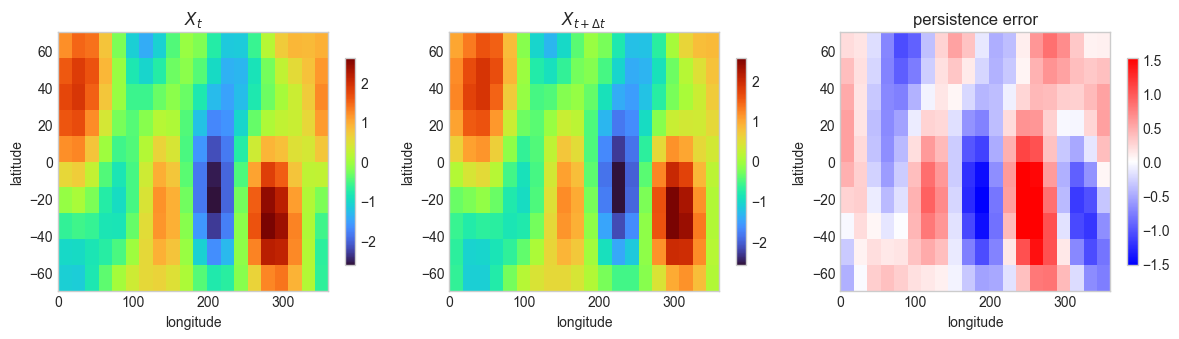

In [6]:
def plot_field(ax, values, title, cmap='turbo', symmetric=False):
    image = values.reshape(grid_shape)
    kwargs = {}
    if symmetric:
        vmax = np.percentile(np.abs(image), 98)
        kwargs.update(vmin=-vmax, vmax=vmax)
    im = ax.imshow(
        image,
        origin='lower',
        extent=[0, 360, lat.min(), lat.max()],
        aspect='auto',
        cmap=cmap,
        **kwargs,
    )
    ax.set_title(title)
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    return im

sample = 0
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
plot_items = [
    (x_test[sample], '$X_t$', 'turbo', False),
    (y_test[sample], '$X_{t+\Delta t}$', 'turbo', False),
    (x_test[sample] - y_test[sample], 'persistence error', 'bwr', True),
]
for ax, (values, title, cmap, symmetric) in zip(axes, plot_items):
    im = plot_field(ax, values, title, cmap=cmap, symmetric=symmetric)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

## 5. A small message-passing forecast model

The model below follows the encoder-processor-decoder pattern:

- Encode the scalar field plus coordinate features into hidden node states.
- Apply several message-passing processor layers.
- Decode the hidden node states into the predicted next scalar field.

The graph is fixed for every sample. Only the node values change from one training example to the next.

In [7]:
class MessagePassingLayer(nn.Module):
    def __init__(self, hidden, edge_dim):
        super().__init__()
        self.message_mlp = nn.Sequential(
            nn.Linear(2 * hidden + edge_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
        )

    def forward(self, h, edge_index, edge_attr):
        src, dst = edge_index
        edge_attr_b = edge_attr.unsqueeze(0).expand(h.shape[0], -1, -1)
        message_input = torch.cat([h[:, src], h[:, dst], edge_attr_b], dim=-1)
        messages = self.message_mlp(message_input)

        aggregated = torch.zeros_like(h)
        aggregated.index_add_(1, dst, messages)
        degree = torch.bincount(dst, minlength=h.shape[1]).to(h.device).view(1, -1, 1)
        aggregated = aggregated / degree.clamp_min(1)

        return h + self.update_mlp(torch.cat([h, aggregated], dim=-1))


class GraphWeatherOperator(nn.Module):
    def __init__(self, hidden=32, steps=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(5, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
        )
        self.processor = nn.ModuleList([
            MessagePassingLayer(hidden, edge_dim=3) for _ in range(steps)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, node_coords, edge_index, edge_attr):
        coords = node_coords.unsqueeze(0).expand(x.shape[0], -1, -1)
        h = self.encoder(torch.cat([x.unsqueeze(-1), coords], dim=-1))
        for layer in self.processor:
            h = layer(h, edge_index, edge_attr)
        return self.decoder(h).squeeze(-1)


def relative_l2_np(pred, truth):
    pred_f = pred.reshape(pred.shape[0], -1)
    truth_f = truth.reshape(truth.shape[0], -1)
    return np.linalg.norm(pred_f - truth_f, axis=1) / np.linalg.norm(truth_f, axis=1)

In [8]:
model = GraphWeatherOperator(hidden=32, steps=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

history = []
n_epochs = 25
batch_size = 16

for epoch in range(1, n_epochs + 1):
    model.train()
    perm = torch.randperm(len(x_train_t), device=device)
    batch_losses = []

    for ids in perm.split(batch_size):
        optimizer.zero_grad(set_to_none=True)
        pred = model(x_train_t[ids], node_coords, edge_index, edge_attr)
        loss = loss_fn(pred, y_train_t[ids])
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        pred_test_n = model(x_test_t, node_coords, edge_index, edge_attr)
        test_mse = loss_fn(pred_test_n, y_test_t).item()

    history.append((epoch, float(np.mean(batch_losses)), test_mse))
    if epoch == 1 or epoch % 5 == 0:
        print(f'epoch {epoch:02d} | train MSE {history[-1][1]:.4f} | test MSE {test_mse:.4f}')

model.eval()
with torch.no_grad():
    pred_test_n = model(x_test_t, node_coords, edge_index, edge_attr).cpu().numpy()

pred_test = pred_test_n * x_std + x_mean
persistence = x_test.copy()

model_rel_l2 = relative_l2_np(pred_test, y_test).mean()
persistence_rel_l2 = relative_l2_np(persistence, y_test).mean()
model_mse = np.mean((pred_test - y_test) ** 2)
persistence_mse = np.mean((persistence - y_test) ** 2)

print(f'graph operator relative L2: {model_rel_l2:.3f}')
print(f'persistence relative L2:   {persistence_rel_l2:.3f}')
print(f'graph operator MSE:         {model_mse:.4f}')
print(f'persistence MSE:            {persistence_mse:.4f}')

epoch 01 | train MSE 0.8929 | test MSE 0.5144
epoch 05 | train MSE 0.3651 | test MSE 0.2954
epoch 10 | train MSE 0.3418 | test MSE 0.2818
epoch 15 | train MSE 0.2281 | test MSE 0.1787
epoch 20 | train MSE 0.0811 | test MSE 0.0683
epoch 25 | train MSE 0.0517 | test MSE 0.0427
graph operator relative L2: 0.232
persistence relative L2:   0.651
graph operator MSE:         0.0449
persistence MSE:            0.3452


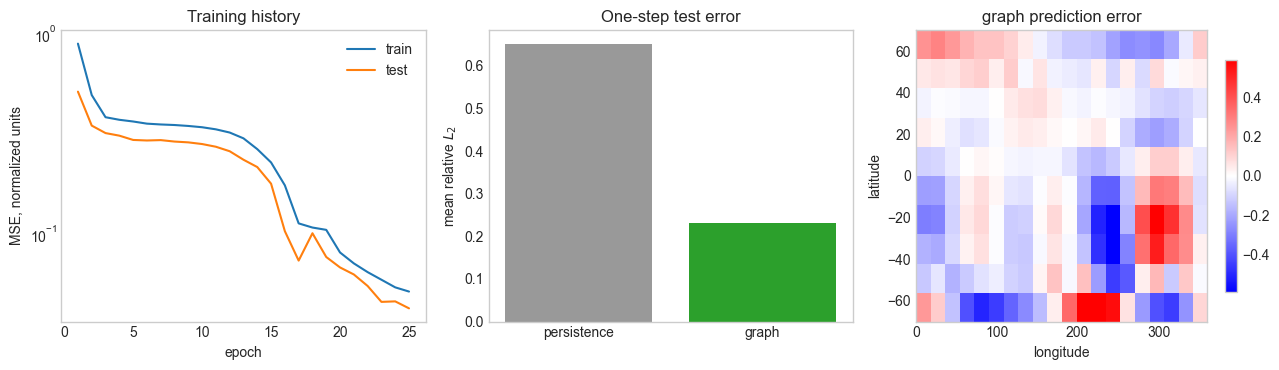

In [9]:
history = np.array(history)
idx = 1

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(history[:, 0], history[:, 1], label='train')
axes[0].plot(history[:, 0], history[:, 2], label='test')
axes[0].set_yscale('log')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE, normalized units')
axes[0].set_title('Training history')
axes[0].legend()

axes[1].bar(['persistence', 'graph'], [persistence_rel_l2, model_rel_l2], color=['0.6', 'tab:green'])
axes[1].set_ylabel('mean relative $L_2$')
axes[1].set_title('One-step test error')

err = pred_test[idx] - y_test[idx]
im = plot_field(axes[2], err, 'graph prediction error', cmap='bwr', symmetric=True)
plt.colorbar(im, ax=axes[2], shrink=0.8)
plt.tight_layout()

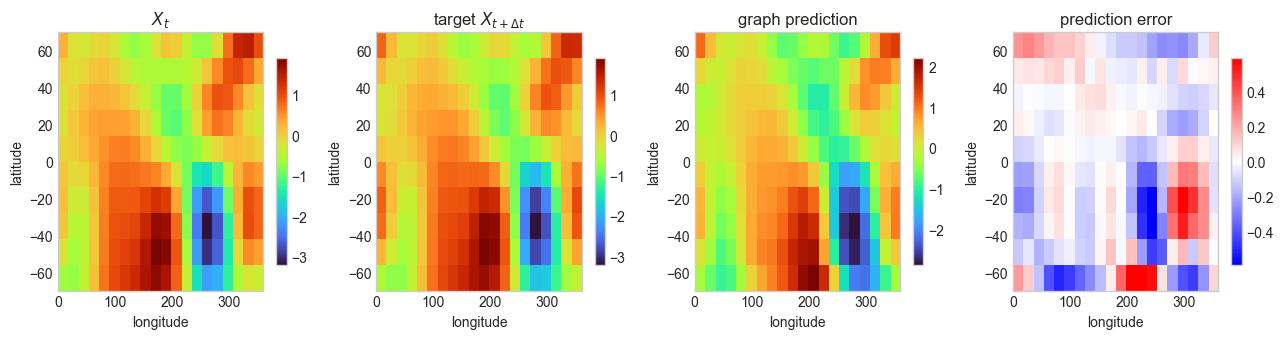

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
fields = [x_test[idx], y_test[idx], pred_test[idx], pred_test[idx] - y_test[idx]]
titles = ['$X_t$', 'target $X_{t+\Delta t}$', 'graph prediction', 'prediction error']
cmaps = ['turbo', 'turbo', 'turbo', 'bwr']
symmetric = [False, False, False, True]

for ax, field, title, cmap, sym in zip(axes, fields, titles, cmaps, symmetric):
    im = plot_field(ax, field, title, cmap=cmap, symmetric=sym)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

The model beats persistence because the graph gives it a mechanism for local transport. It can aggregate nearby upstream values and combine them with edge geometry. That is the core weather-operator idea here, not the exact architecture or toy score.

## 6. Connectivity and receptive field

Each message-passing layer moves information by one graph hop. With three processor layers, a node can depend on information from nodes up to about three hops away.

This is one reason production graph weather models use carefully designed multi-scale meshes: local edges are good for local transport, but medium-range forecasting also needs fast communication across large distances.

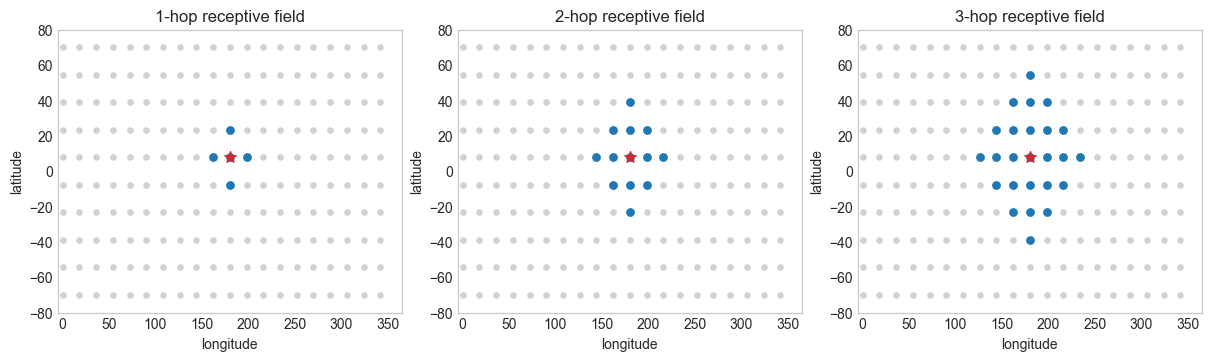

In [11]:
def k_hop_nodes(edge_index_np, start, hops):
    incoming = [[] for _ in range(len(lat))]
    for src, dst in edge_index_np.T:
        incoming[dst].append(src)

    seen = {start}
    frontier = {start}
    for _ in range(hops):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(incoming[node])
        next_frontier -= seen
        seen |= next_frontier
        frontier = next_frontier
    return np.array(sorted(seen))

center_node = np.argmin((lat - 0.0) ** 2 + ((lon - 180.0 + 180) % 360 - 180) ** 2)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
for ax, hops in zip(axes, [1, 2, 3]):
    reached = k_hop_nodes(edge_index_np, center_node, hops)
    ax.scatter(lon, lat, s=14, c='0.82')
    ax.scatter(lon[reached], lat[reached], s=28, c='tab:blue')
    ax.scatter(lon[center_node], lat[center_node], s=70, c='tab:red', marker='*')
    ax.set_xlim(-5, 365)
    ax.set_ylim(-80, 80)
    ax.set_title(f'{hops}-hop receptive field')
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
plt.show()

## 7. Link to Keisler 2022

Keisler's [Forecasting Global Weather with Graph Neural Networks](https://arxiv.org/abs/2202.07575) applied this idea to real global weather prediction. The model learned to advance a 3D atmospheric state by six hours and then chained the learned step autoregressively for multi-day forecasts.

The paper's setting is much larger than our toy problem:

- inputs come from ERA5 reanalysis or GFS forecast data,
- the state includes many atmospheric variables and vertical levels,
- forecast skill is evaluated on meteorological variables such as Z500 and T850,
- multi-step rollout behavior matters, not just one-step training error.

The operator-learning connection is direct:

$$
X_t \mapsto X_{t+6\,\mathrm{h}} \mapsto X_{t+12\,\mathrm{h}} \mapsto \cdots.
$$

The difference from FNO/SFNO is the spatial representation: graph message passing rather than spectral mode mixing.

## 8. Preparing for AIFS-style systems

This notebook gives the conceptual pieces needed for AIFS and related systems:

- graph or mesh flexibility for spherical data,
- learned latent processing instead of hand-coded numerical time stepping,
- encoder-processor-decoder structure,
- autoregressive forecast operators,
- attention or message passing as ways to move information across the globe.

ECMWF's AIFS is a much larger operational system. ECMWF describes the early AIFS as inspired by graph neural weather models, and later updates describe attention-based graph neural networks for the encoder and decoder with a sliding-window transformer processor. Those operational choices are the focus of the next notebook.

## 9. Takeaways

- Graphs represent weather fields as node features connected by edges.
- Message passing is a learned spatial operator on that graph.
- Encoder-processor-decoder models separate data ingestion, latent evolution, and output projection.
- A graph forecast model can learn a reusable one-step operator and roll it forward autoregressively.
- Graph-based models are a natural bridge from spectral neural operators to modern AIFS-style forecasting systems.